In [4]:
import pandas as pd

from notebooks.consts import OLIGO_CSV_PROCESSED_AVERAGED

data = pd.read_csv(OLIGO_CSV_PROCESSED_AVERAGED)

In [5]:
data.columns

Index(['index_oligo', 'Sequence', 'chemistry', 'custom_id', 'target_mrna',
       'target_gene', 'Cell_line', 'Cell line organism', 'ASO_volume(nM)',
       'cells_per_well', 'transfection_method', 'steric_blocking',
       'rna_context', 'sugar_mods', 'backbone_mods', 'rna_sequence',
       'patent_id', 'split', 'Canonical Gene Name', 'sense_start',
       'sense_start_from_end', 'sense_length', 'sense_exon', 'sense_intron',
       'sense_utr', 'sense_type', 'Chemical_Pattern', 'Modification',
       'ps_pattern', 'cohort_id', 'Cell_Line_Depmap_Proxy', 'Cell_Line_Depmap',
       'Inhibition(%)'],
      dtype='object')

Found 19 models. Extracting feature importances...
Universal Feature Matrix shape: 546 unique features x 19 models.
Identified 4 Hepatic cell lines: ['Huh7', 'Hep3B', 'HepG2', 'HepaRG']


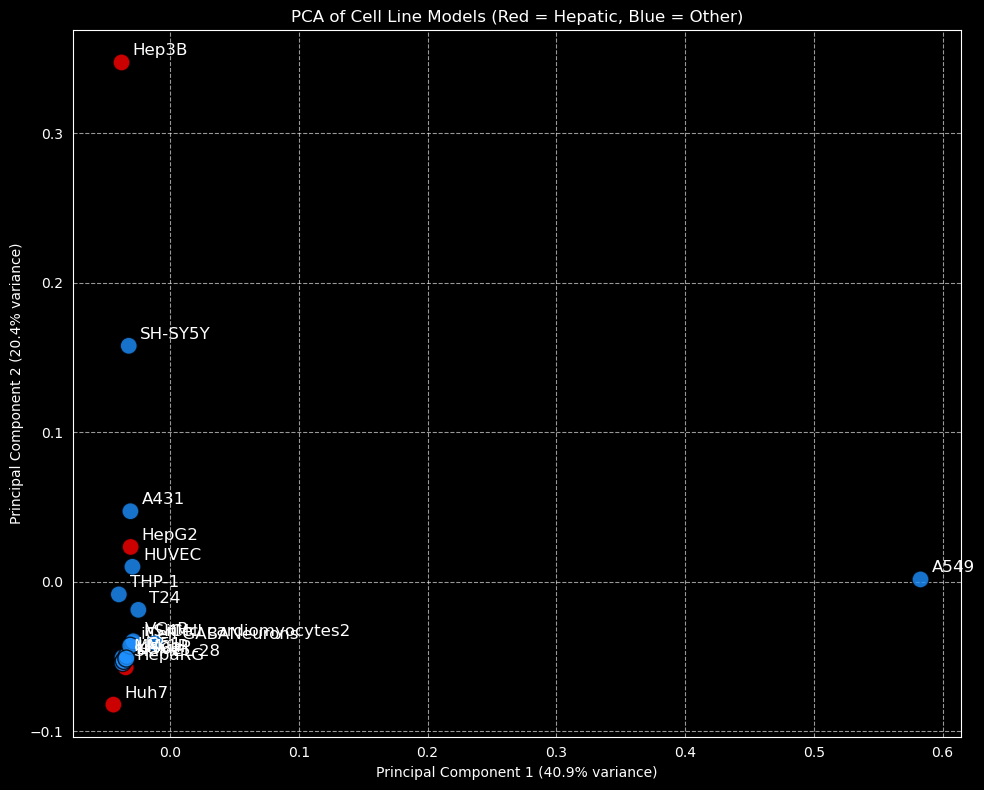

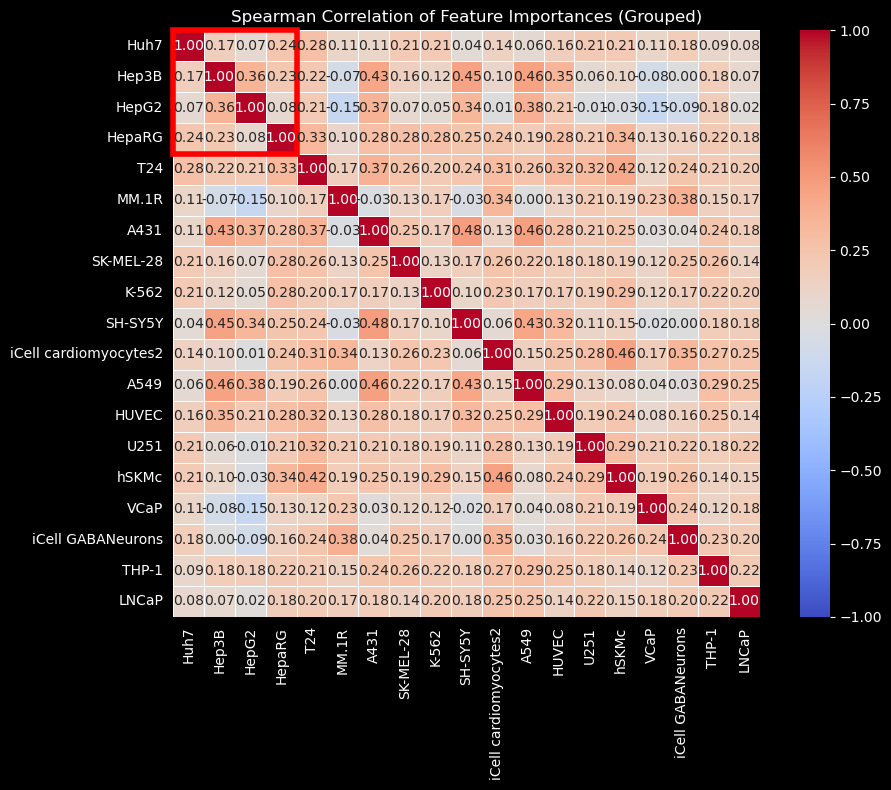

<Figure size 1200x1000 with 0 Axes>

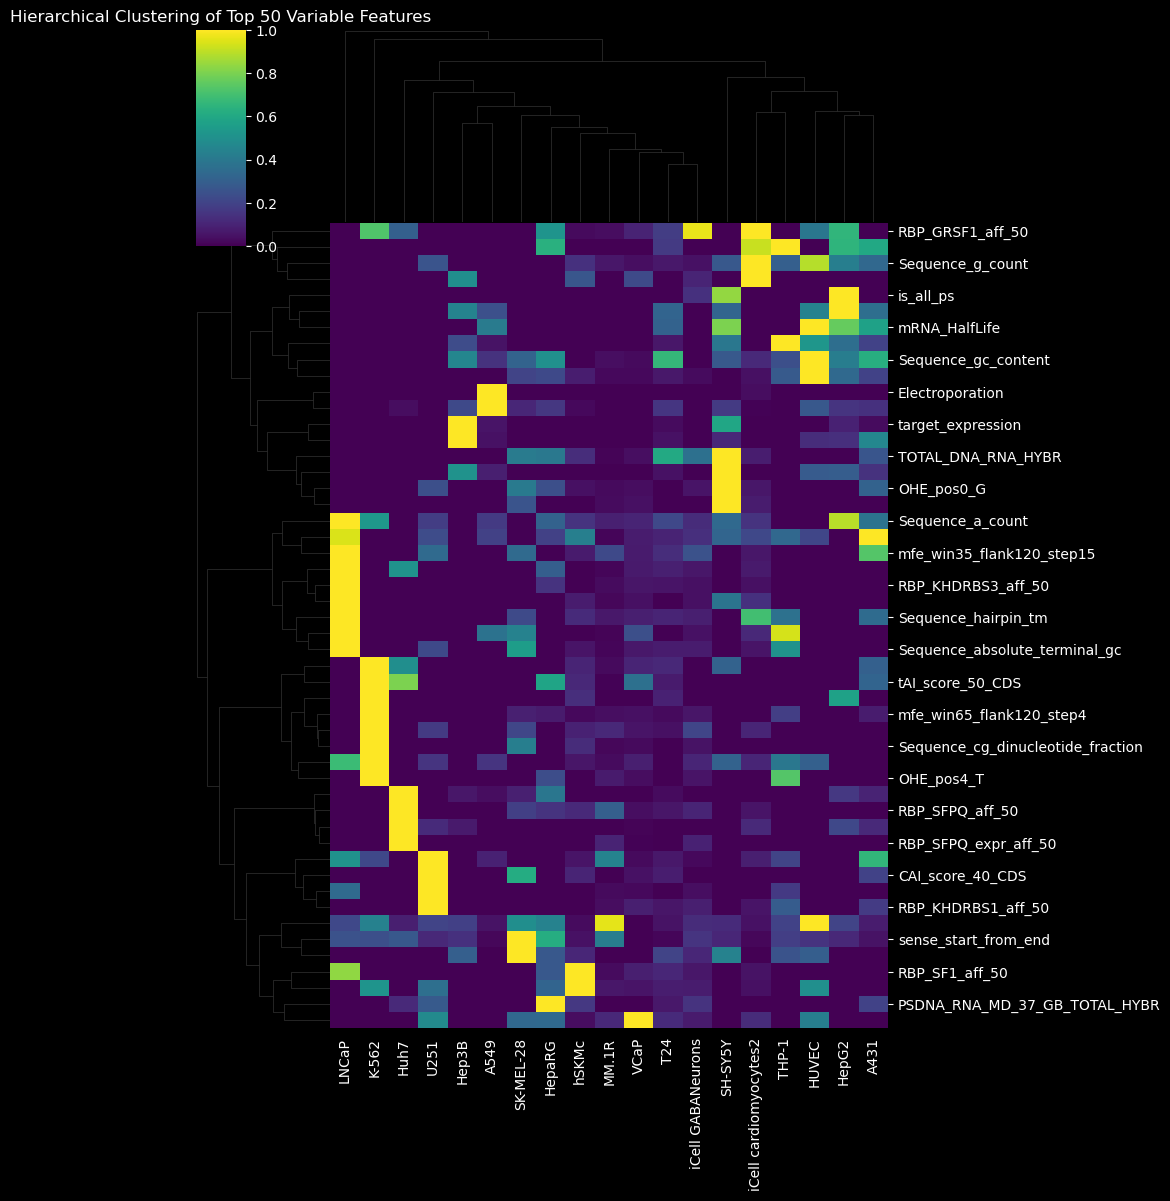

In [6]:
from tauso.data.consts import CELL_LINE_TO_DEPMAP_PROXY_DICT, HEPA_PROXIES
import pandas as pd
import numpy as np
import xgboost as xgb
import glob
import os
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from sklearn.decomposition import PCA
from scipy.spatial.distance import pdist, squareform

# ==========================================
# 1. Load Models and Extract Importances
# ==========================================
model_files = glob.glob('Model_*.json')
importance_dicts = {}

print(f"Found {len(model_files)} models. Extracting feature importances...")

for file in model_files:
    cell_line = os.path.basename(file).replace('Model_', '').replace('.json', '')

    bst = xgb.Booster()
    bst.load_model(file)

    importances = bst.get_score(importance_type='gain')
    importance_dicts[cell_line] = importances

# 2. Build the Universal Feature Matrix
df_importances = pd.DataFrame(importance_dicts)
df_importances = df_importances.fillna(0.0)

print(f"Universal Feature Matrix shape: {df_importances.shape[0]} unique features x {df_importances.shape[1]} models.")

df_normalized = df_importances.div(df_importances.sum(axis=0), axis=1)

# ==========================================
# 3. Apply Hepa Grouping Logic
# ==========================================
valid_cell_lines = df_normalized.columns.tolist()
hepa_cells = []
other_cells = []

for cl in valid_cell_lines:
    proxy = CELL_LINE_TO_DEPMAP_PROXY_DICT.get(cl, cl)
    if proxy in HEPA_PROXIES or cl in HEPA_PROXIES:
        hepa_cells.append(cl)
    else:
        other_cells.append(cl)

grouped_cell_lines = hepa_cells + other_cells
num_hepa = len(hepa_cells)

print(f"Identified {num_hepa} Hepatic cell lines: {hepa_cells}")

# Reorder the DataFrame so Hepa cells are strictly the first columns
df_normalized = df_normalized[grouped_cell_lines]

# ==========================================
# VISUALIZATION 1: PCA of Models
# ==========================================
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_normalized.T)

# Create color array (Red for Hepa, Blue for Others)
point_colors = ['red' if cl in hepa_cells else 'dodgerblue' for cl in df_normalized.columns]

plt.figure(figsize=(10, 8))
plt.scatter(pca_result[:, 0], pca_result[:, 1], s=150, alpha=0.8, c=point_colors, edgecolors='k')

# Annotate points
for i, cell_line in enumerate(df_normalized.columns):
    plt.annotate(cell_line, (pca_result[i, 0], pca_result[i, 1]),
                 xytext=(8, 5), textcoords='offset points', fontsize=12)

plt.title('PCA of Cell Line Models (Red = Hepatic, Blue = Other)')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('PCA_Models.png', dpi=300)
plt.show()

# ==========================================
# VISUALIZATION 2: Spearman Correlation Heatmap
# ==========================================
# Because we reordered df_normalized above, corr_matrix is automatically grouped
corr_matrix = df_normalized.corr(method='spearman')

plt.figure(figsize=(10, 8))
ax = sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1,
                 fmt=".2f", square=True, linewidths=0.5)

# Draw the red bounding box around the Hepa cluster
if num_hepa > 0:
    ax.add_patch(patches.Rectangle((0, 0), num_hepa, num_hepa, fill=False,
                                   edgecolor='red', lw=4, clip_on=False))

plt.title('Spearman Correlation of Feature Importances (Grouped)')
plt.tight_layout()
plt.savefig('Model_Correlation_Heatmap.png', dpi=300)
plt.show()

# ==========================================
# VISUALIZATION 3: Hierarchical Clustermap
# ==========================================
plt.figure(figsize=(12, 10))
top_features = df_normalized.var(axis=1).nlargest(50).index
df_top = df_normalized.loc[top_features]

# Note: Clustermap calculates its own dendrogram and will rearrange columns automatically
# based on similarity, which might override our strict Hepa grouping. This is desired
# behavior to see true mathematical clusters!
sns.clustermap(df_top, cmap='viridis', standard_scale=0,
               figsize=(10, 12), method='ward', metric='euclidean')
plt.title('Hierarchical Clustering of Top 50 Variable Features')
plt.savefig('Hierarchical_Clustermap.png', dpi=300)
plt.show()